In [73]:
import os
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from pylab import rcParams


In [ ]:
url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/32.4653%2C35.8053/2025-01-01/2026-07-28?unitGroup=metric&include=days&key=BUHR8LMJ3EZCBM56UUTU8BNGN&contentType=json"
r = requests.get(url)
weather = r.json()
with open("weather_data.json", "w", encoding = "utf-8") as f:
    json.dump(weather, f, ensure_ascii = False, indent = 4)
print("saved successfully")
print(weather)

In [74]:
with open(r"C:\Users\USER\weather_data.json", "r", encoding = "utf-8") as f:
    data = json.load(f)

weather_df = pd.DataFrame(data["days"])

important_columns = [
    'datetime', 'temp', 'tempmax', 'tempmin', 
    'feelslike', 'feelslikemax', 'feelslikemin', 
    'humidity', 'dew', 'precip', 'precipprob', 
    'windspeed', 'pressure', 'cloudcover', 
    'solarenergy', 'uvindex'
]

# تصفية الداتا فريم للاحتفاظ بالأعمدة المهمة فقط (مع التأكد من وجودها)
existing_columns = [col for col in important_columns if col in weather_df.columns]
weather_df = weather_df[existing_columns]

for col in weather_df.columns:
    non_null = weather_df[col].dropna()

    if not non_null.empty:
        print(col, type(non_null.iloc[0]))
    else:
        print(col, "All values are NaN")

datetime <class 'str'>
temp <class 'numpy.float64'>
tempmax <class 'numpy.float64'>
tempmin <class 'numpy.float64'>
feelslike <class 'numpy.float64'>
feelslikemax <class 'numpy.float64'>
feelslikemin <class 'numpy.float64'>
humidity <class 'numpy.float64'>
dew <class 'numpy.float64'>
precip <class 'numpy.float64'>
precipprob <class 'numpy.float64'>
windspeed <class 'numpy.float64'>
pressure <class 'numpy.float64'>
cloudcover <class 'numpy.float64'>
solarenergy <class 'numpy.float64'>
uvindex <class 'numpy.float64'>


In [75]:
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df.set_index("datetime", inplace = True)
weather_df.sort_index(inplace=True)
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 574 entries, 2025-01-01 to 2026-07-28
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          574 non-null    float64
 1   tempmax       574 non-null    float64
 2   tempmin       574 non-null    float64
 3   feelslike     574 non-null    float64
 4   feelslikemax  574 non-null    float64
 5   feelslikemin  574 non-null    float64
 6   humidity      574 non-null    float64
 7   dew           574 non-null    float64
 8   precip        574 non-null    float64
 9   precipprob    574 non-null    float64
 10  windspeed     574 non-null    float64
 11  pressure      574 non-null    float64
 12  cloudcover    574 non-null    float64
 13  solarenergy   574 non-null    float64
 14  uvindex       574 non-null    float64
dtypes: float64(15)
memory usage: 71.8 KB


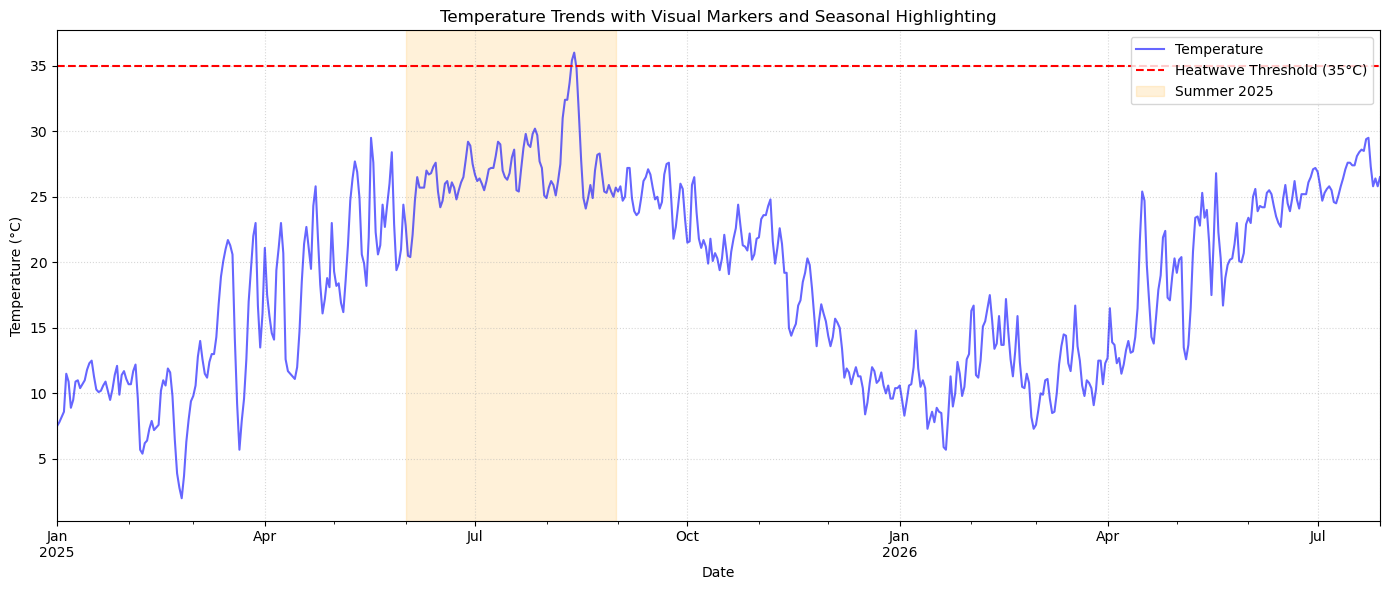

In [76]:
ax = weather_df['temp'].plot(figsize=(14, 6), color='blue', alpha=0.6, label='Temperature')

ax.axhline(35, color='red', linestyle='--', linewidth=1.5, label='Heatwave Threshold (35°C)')

ax.axvspan(pd.Timestamp('2025-06-01'), pd.Timestamp('2025-08-31'), color='orange', alpha=0.15, label='Summer 2025')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Trends with Visual Markers and Seasonal Highlighting')
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


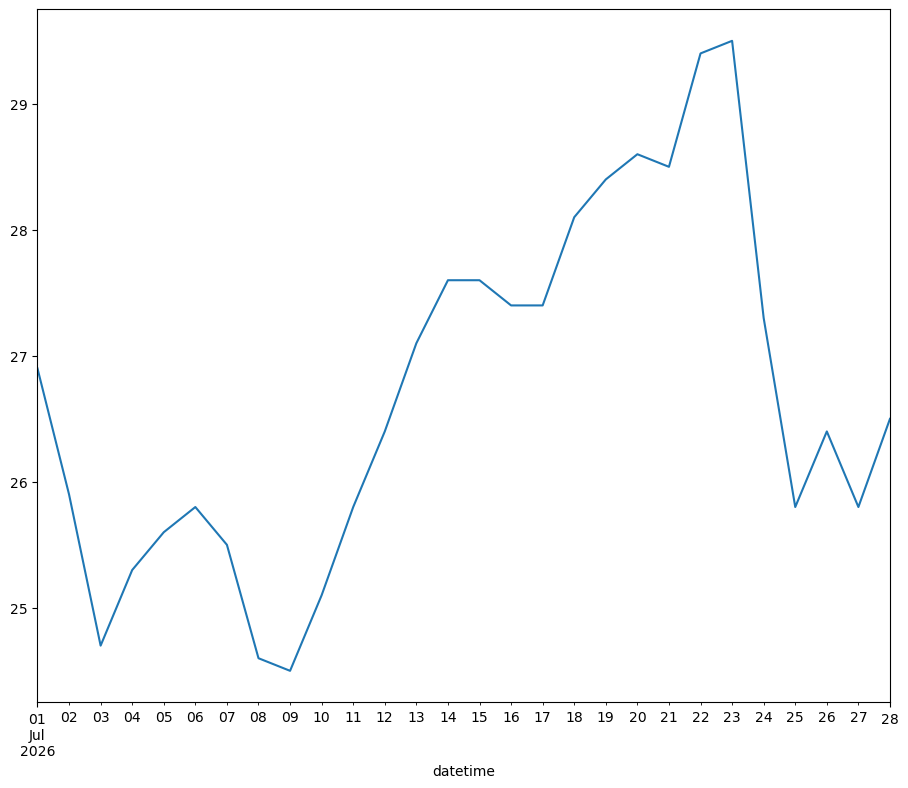

In [77]:
weather_df.loc["2026-07-01":"2026-07-28", "temp"].plot()
plt.show()

In [78]:
weather_df["temp"].describe()


count    574.000000
mean      18.714460
std        6.997952
min        2.000000
25%       11.925000
50%       19.900000
75%       25.000000
max       36.000000
Name: temp, dtype: float64

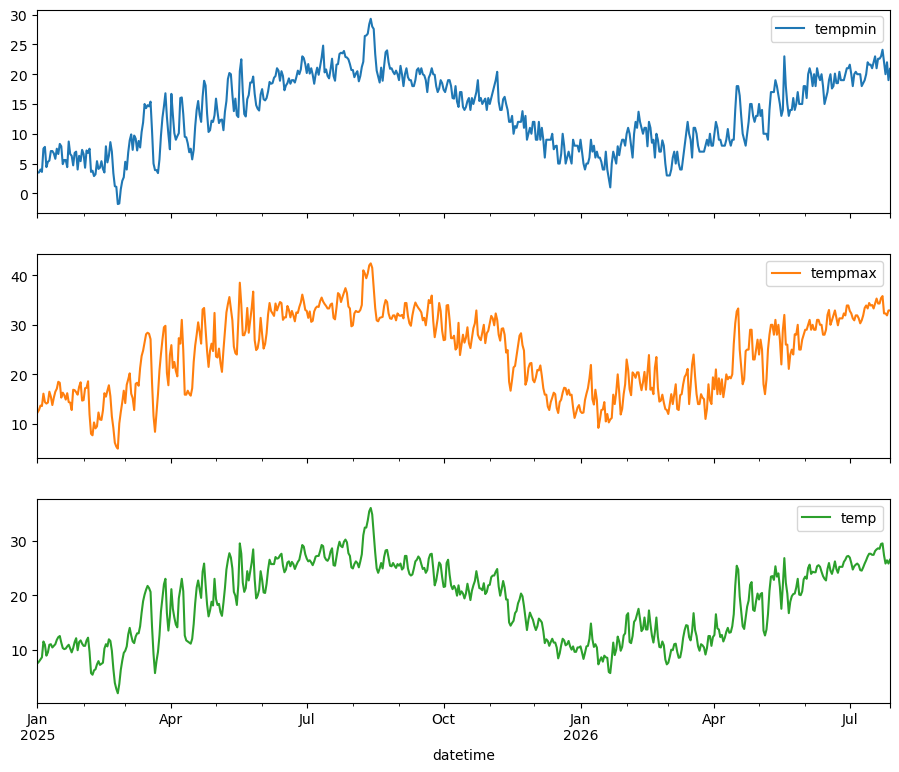

In [79]:
weather_df[["tempmin", "tempmax", "temp"]].plot(subplots = True)
plt.show()

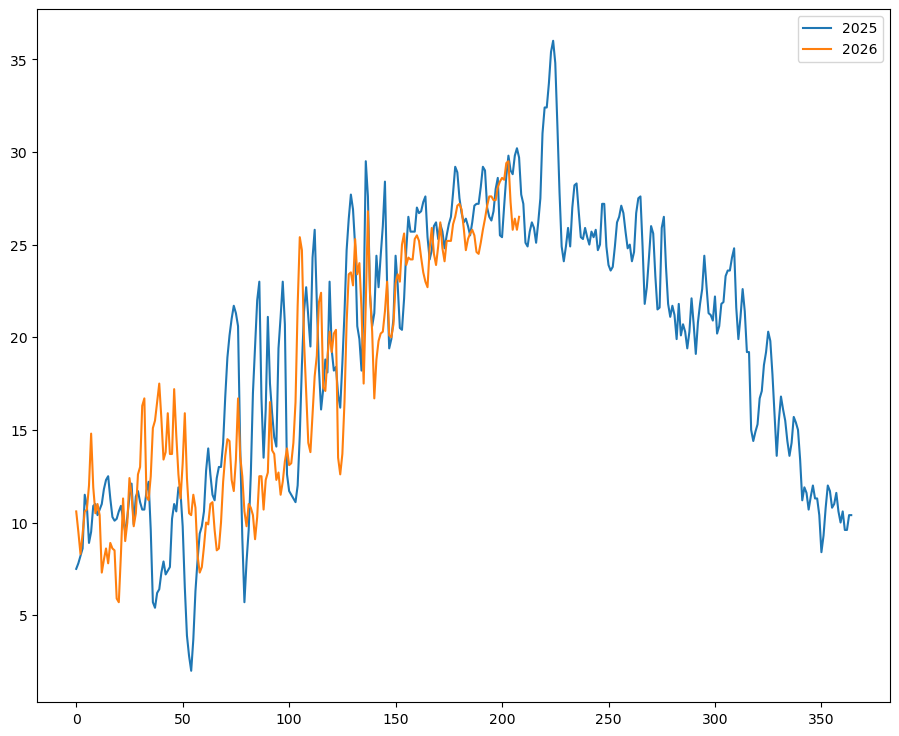

In [80]:
temps = pd.DataFrame()
for year in ["2025", "2026"]:
    temp_per_year = weather_df.loc[year, ["temp"]].reset_index(drop = True)
    temp_per_year.rename(columns={"temp": year}, inplace=True)
    temps = pd.concat([temps, temp_per_year], axis = 1)
temps.plot()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17548\2952846082.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weather_df_M = weather_df.asfreq("M")


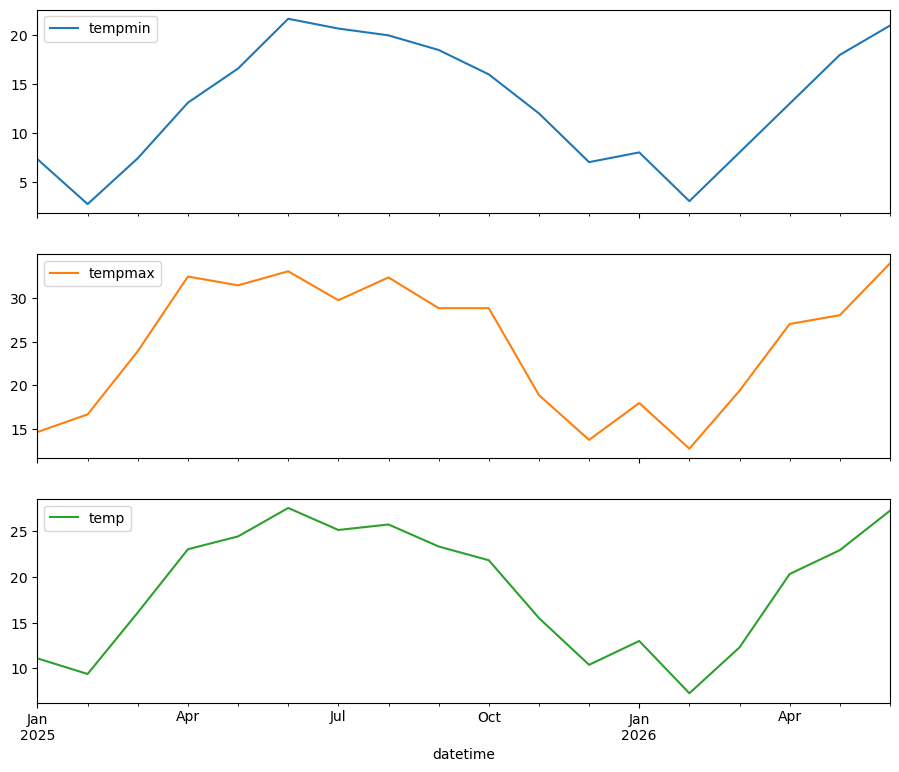

In [81]:
weather_df_M = weather_df.asfreq("M")
weather_df_M[["tempmin", "tempmax", "temp"]].plot(subplots = True)
plt.show()

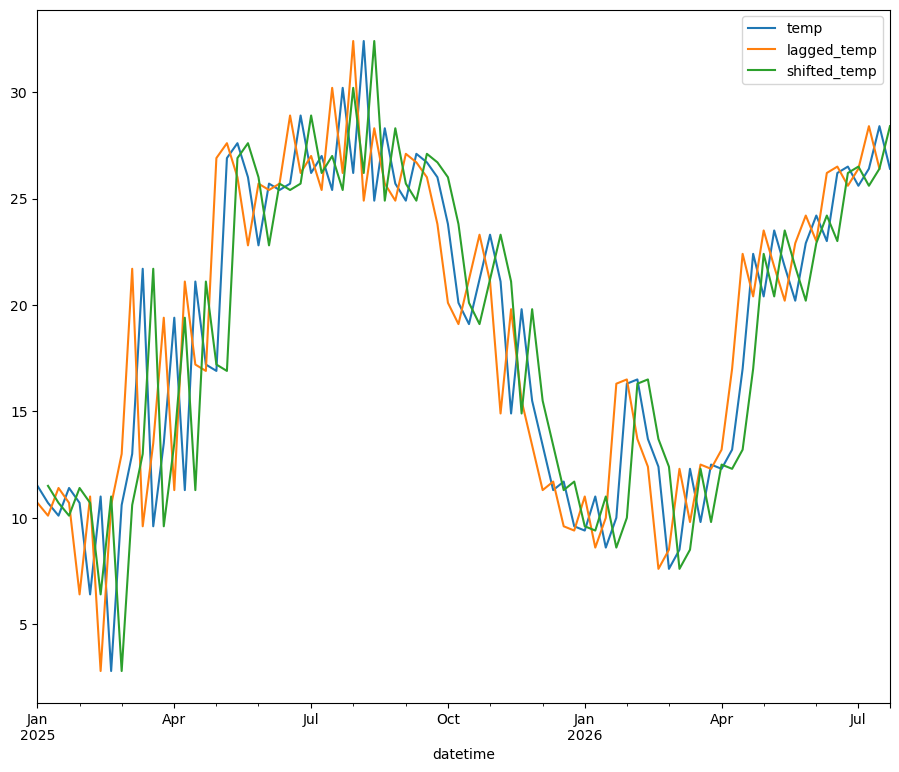

In [82]:
weather_df_W = weather_df.asfreq("W")
weather_df_W["lagged_temp"] = weather_df_W.temp.shift(periods = -1)
weather_df_W["shifted_temp"] = weather_df_W.temp.shift(periods = 1)
weather_df_W[["temp", "lagged_temp", "shifted_temp"]].plot()
plt.show()

In [83]:
weather_df_W["change_temp"] = weather_df_W.temp - weather_df_W.shifted_temp
weather_df_W["diff_temp"] = weather_df_W.temp.diff(periods = 1)
print(weather_df_W.tail())
print(weather_df_W.change_temp.sub(weather_df_W.diff_temp).value_counts())

            temp  tempmax  tempmin  feelslike  feelslikemax  feelslikemin  \
datetime                                                                    
2026-06-28  26.5     31.9     20.0       26.4          31.2          20.0   
2026-07-05  25.6     31.9     20.4       25.9          32.6          20.4   
2026-07-12  26.4     33.9     20.0       26.1          32.6          20.0   
2026-07-19  28.4     35.3     21.0       27.4          33.2          21.0   
2026-07-26  26.4     31.9     22.0       26.3          31.1          22.0   

            humidity   dew  precip  precipprob  windspeed  pressure  \
datetime                                                              
2026-06-28      42.5  12.4     0.0         0.0       21.0    1012.5   
2026-07-05      61.1  17.1     0.0         0.0       25.9    1009.8   
2026-07-12      41.2  11.8     0.0         0.0       22.3    1012.4   
2026-07-19      31.2   9.0     0.0         0.0       24.3    1012.7   
2026-07-26      46.3  13.7     0.0

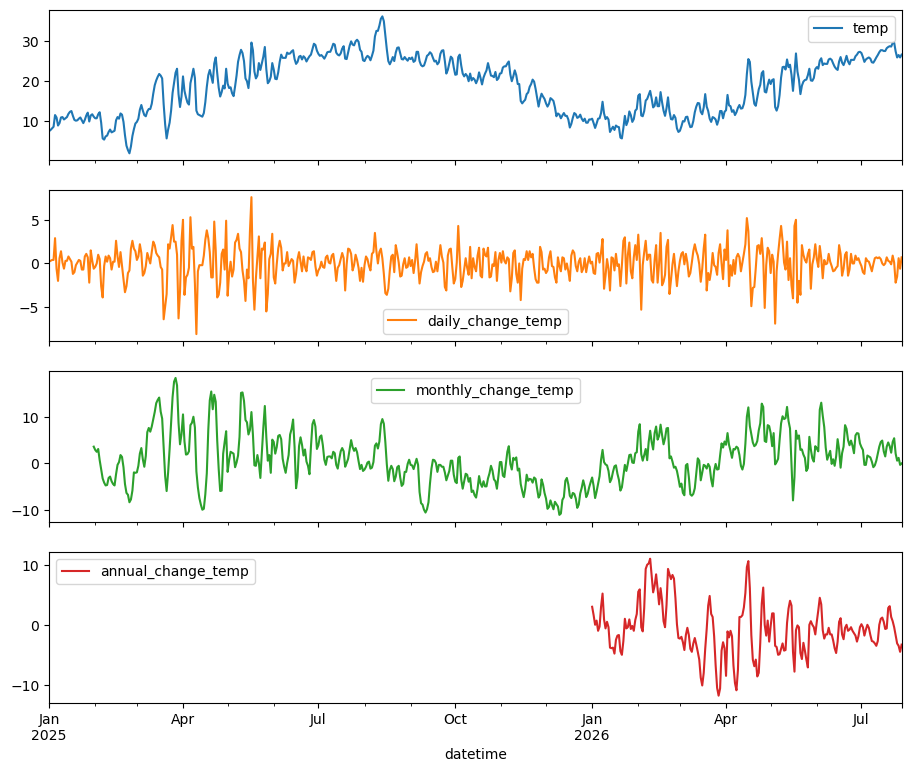

In [84]:
weather_df['daily_change_temp'] = weather_df['temp'].diff(periods=1)
weather_df['monthly_change_temp'] = weather_df['temp'].diff(periods=30) 
weather_df['annual_change_temp'] = weather_df['temp'].diff(periods=365) 
weather_df[["temp", "daily_change_temp", "monthly_change_temp", "annual_change_temp"]].plot(subplots = True)
plt.show()

In [85]:
weather_df.asfreq('MS').info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2025-01-01 to 2026-07-01
Freq: MS
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp                 19 non-null     float64
 1   tempmax              19 non-null     float64
 2   tempmin              19 non-null     float64
 3   feelslike            19 non-null     float64
 4   feelslikemax         19 non-null     float64
 5   feelslikemin         19 non-null     float64
 6   humidity             19 non-null     float64
 7   dew                  19 non-null     float64
 8   precip               19 non-null     float64
 9   precipprob           19 non-null     float64
 10  windspeed            19 non-null     float64
 11  pressure             19 non-null     float64
 12  cloudcover           19 non-null     float64
 13  solarenergy          19 non-null     float64
 14  uvindex              19 non-null     float64
 15  daily_change_

In [86]:
weather_df.resample("MS")

In [87]:
weather_df['temp'].skew()

np.float64(-0.10364029732613428)

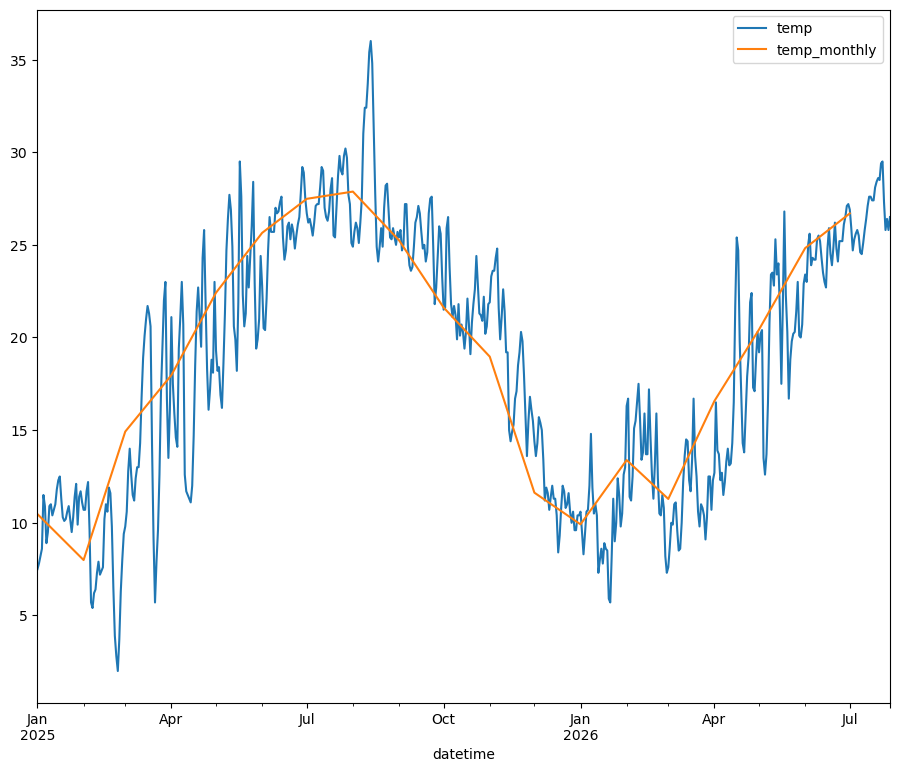

In [88]:
weather_df_2025 = weather_df.loc[:, ["temp"]]
ax = weather_df_2025.plot()
monthly = weather_df_2025.resample('ME').mean()
monthly.add_suffix('_monthly').plot(ax = ax)
plt.show()

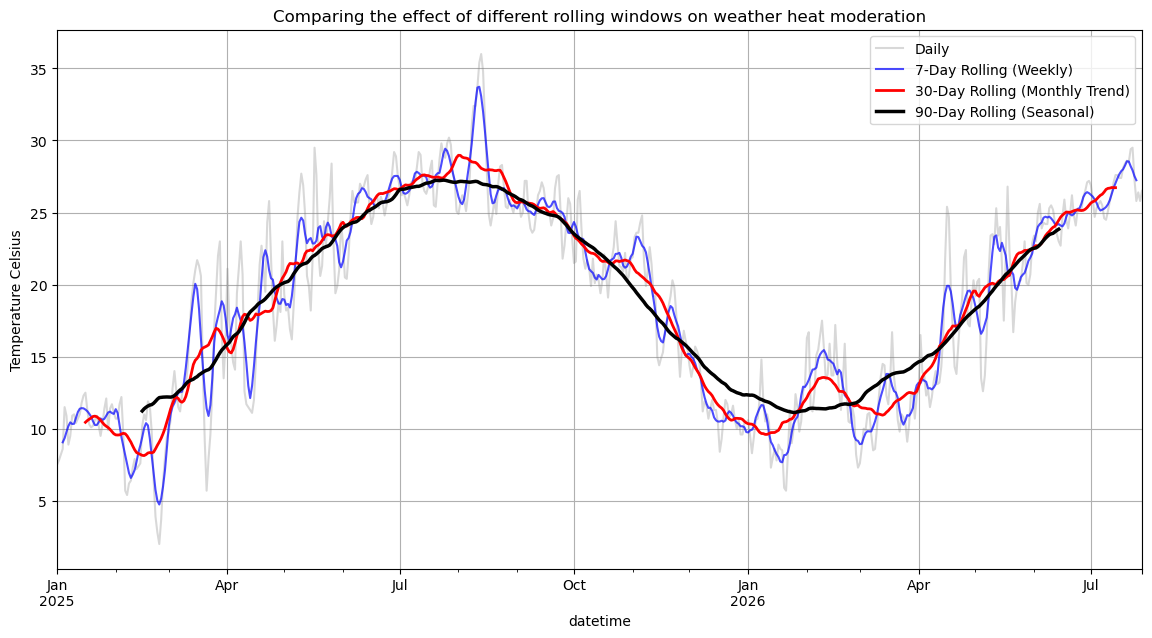

In [89]:
ax = weather_df["temp"].plot(figsize=(14, 7), color="gray", alpha=0.3, label="Daily")

weather_df["temp"].rolling(window=7, center=True).mean().plot(ax=ax, color="blue", alpha=0.7, label="7-Day Rolling (Weekly)")
weather_df["temp"].rolling(window=30, center=True).mean().plot(ax=ax, color="red", linewidth=2, label="30-Day Rolling (Monthly Trend)")
weather_df["temp"].rolling(window=90, center=True).mean().plot(ax=ax, color="black", linewidth=2.5, label="90-Day Rolling (Seasonal)")

plt.title("Comparing the effect of different rolling windows on weather heat moderation")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.grid(True)
plt.show()


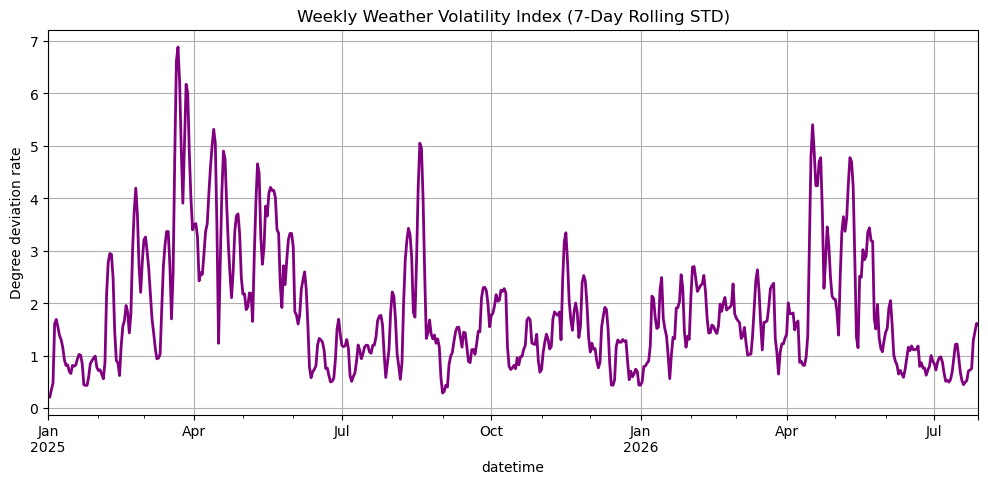

In [90]:
weather_df["temp_volatility"] = weather_df["temp"].rolling(window="7D").std()

plt.figure(figsize=(12, 5))
weather_df["temp_volatility"].plot(color="purple", linewidth=2)

plt.title("Weekly Weather Volatility Index (7-Day Rolling STD)")
plt.ylabel("Degree deviation rate")
plt.grid(True)
plt.show()


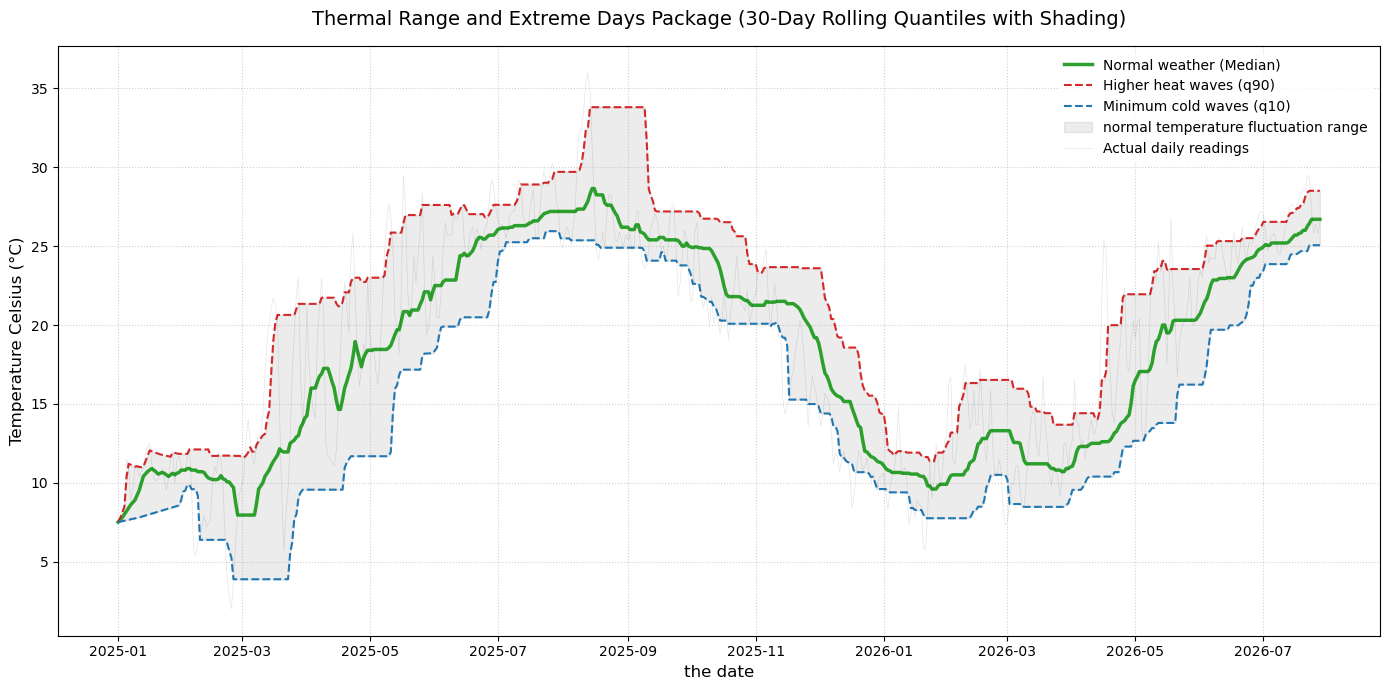

In [91]:
rolling = weather_df['temp'].rolling('30D')

q10 = rolling.quantile(0.1)
median = rolling.median()
q90 = rolling.quantile(0.9)

plt.figure(figsize=(14, 7))

plt.plot(median.index, median, color='#2ca02c', linewidth=2.5, label='Normal weather (Median)')
plt.plot(q90.index, q90, color='#d62728', linestyle='--', linewidth=1.5, label='Higher heat waves (q90)')
plt.plot(q10.index, q10, color='#1f77b4', linestyle='--', linewidth=1.5, label='Minimum cold waves (q10)')

plt.fill_between(median.index, q10, q90, color='gray', alpha=0.15, label='normal temperature fluctuation range')

plt.plot(weather_df.index, weather_df['temp'], color='black', alpha=0.1, linewidth=0.5, label='Actual daily readings')

plt.title("Thermal Range and Extreme Days Package (30-Day Rolling Quantiles with Shading)", fontsize=14, pad=15)
plt.ylabel("Temperature Celsius (°C)", fontsize=12)
plt.xlabel("the date", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


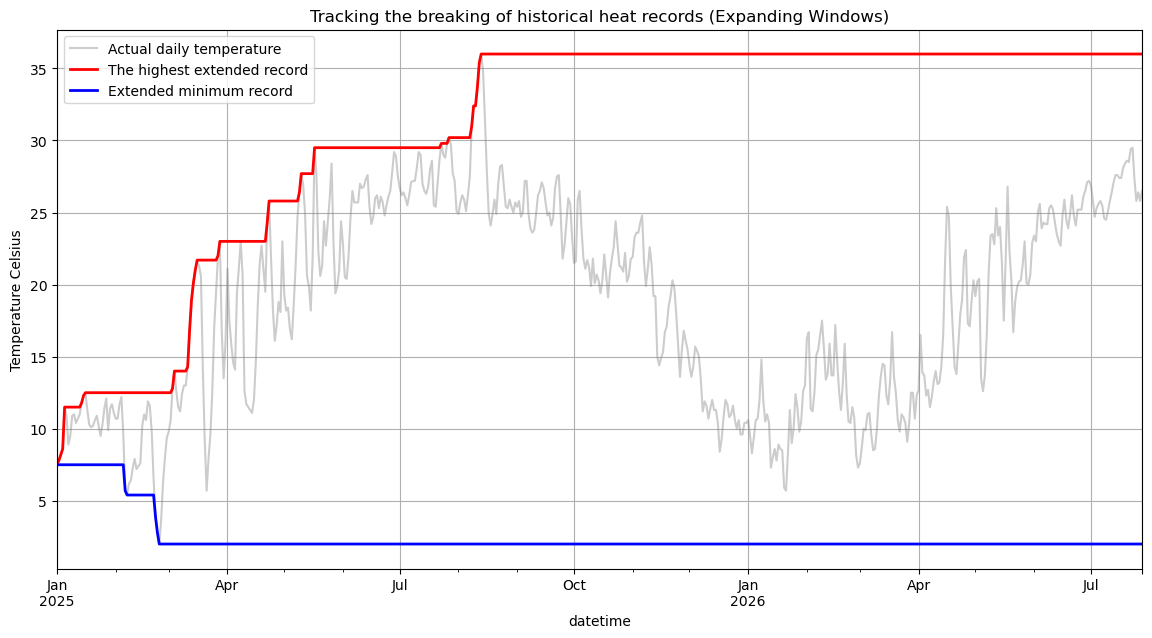

In [92]:
weather_df['record_high'] = weather_df['temp'].expanding().max()
weather_df['record_low'] = weather_df['temp'].expanding().min()

ax = weather_df['temp'].plot(figsize=(14, 7), color='gray', alpha=0.4, label='Actual daily temperature')
weather_df['record_high'].plot(ax=ax, color='red', linewidth=2, label='The highest extended record')
weather_df['record_low'].plot(ax=ax, color='blue', linewidth=2, label='Extended minimum record')

plt.title("Tracking the breaking of historical heat records (Expanding Windows)")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.grid(True)
plt.show()


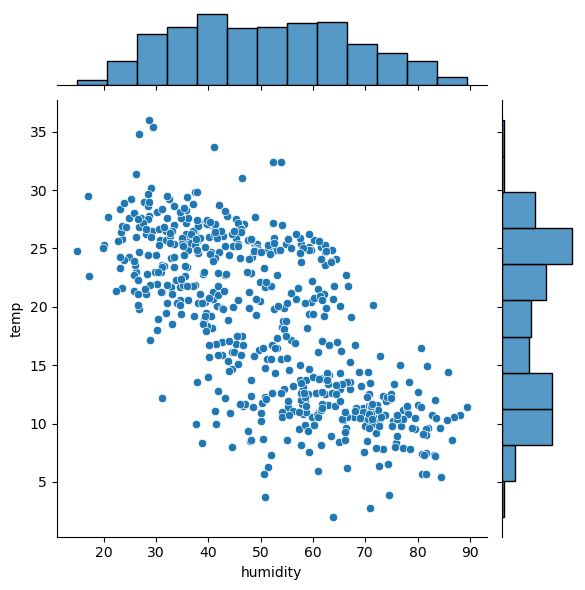

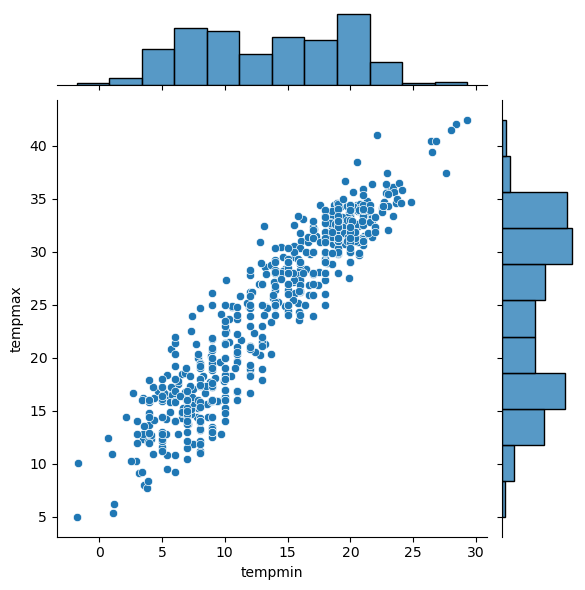

In [93]:
sns.jointplot(x = 'humidity', y = "temp", data = weather_df)
plt.show()
sns.jointplot(x = 'tempmin', y = 'tempmax', data = weather_df)
plt.show()

In [94]:
correlations = weather_df.corr(numeric_only=True)
correlations

,temp,tempmax,tempmin,feelslike,feelslikemax,feelslikemin,humidity,dew,precip,precipprob,...,pressure,cloudcover,solarenergy,uvindex,daily_change_temp,monthly_change_temp,annual_change_temp,temp_volatility,record_high,record_low
temp,1.000000,0.987216,0.976431,0.997092,0.982551,0.982233,-0.704334,0.597034,-0.305311,-0.450344,...,-0.605158,-0.597088,0.768420,0.747768,0.126866,0.383664,0.092579,-0.055341,0.355704,-0.389817
tempmax,0.987216,1.000000,0.938276,0.986669,0.994670,0.952815,-0.734916,0.547679,-0.351090,-0.500227,...,-0.548127,-0.649495,0.778180,0.768269,0.198694,0.389191,0.084009,-0.039430,0.335757,-0.381050
tempmin,0.976431,0.938276,1.000000,0.971630,0.936789,0.991559,-0.607146,0.669458,-0.230650,-0.362125,...,-0.650047,-0.496029,0.704091,0.674706,0.022904,0.330259,0.081971,-0.086522,0.391280,-0.392310
feelslike,0.997092,0.986669,0.971630,1.000000,0.987610,0.983181,-0.696054,0.608984,-0.330627,-0.468064,...,-0.591963,-0.598725,0.763473,0.745667,0.127049,0.382215,0.099792,-0.053289,0.357547,-0.387877
feelslikemax,0.982551,0.994670,0.936789,0.987610,1.000000,0.953089,-0.705095,0.583252,-0.368000,-0.504669,...,-0.548669,-0.637841,0.768288,0.761050,0.189747,0.377022,0.082826,-0.042161,0.344305,-0.382890
feelslikemin,0.982233,0.952815,0.991559,0.983181,0.953089,1.000000,-0.635515,0.652471,-0.285190,-0.413983,...,-0.614490,-0.532831,0.717962,0.694720,0.047036,0.341035,0.097835,-0.082723,0.378857,-0.382991
humidity,-0.704334,-0.734916,-0.607146,-0.696054,-0.705095,-0.635515,1.000000,0.129071,0.419578,0.523998,...,0.271154,0.646346,-0.680142,-0.672666,-0.299966,-0.505241,-0.164215,-0.075898,-0.128213,0.244957
dew,0.597034,0.547679,0.669458,0.608984,0.583252,0.652471,0.129071,1.000000,-0.016863,-0.096802,...,-0.529106,-0.137864,0.331652,0.316531,-0.175694,-0.063832,-0.032995,-0.180833,0.343192,-0.259875
precip,-0.305311,-0.351090,-0.230650,-0.330627,-0.368000,-0.285190,0.419578,-0.016863,1.000000,0.625507,...,-0.119112,0.475135,-0.357532,-0.368155,-0.221903,-0.148857,-0.039303,-0.002169,0.021251,0.026733
precipprob,-0.450344,-0.500227,-0.362125,-0.468064,-0.504669,-0.413983,0.523998,-0.096802,0.625507,1.000000,...,-0.010552,0.596911,-0.439065,-0.460123,-0.203375,-0.206692,-0.108730,0.018068,-0.100119,0.147012


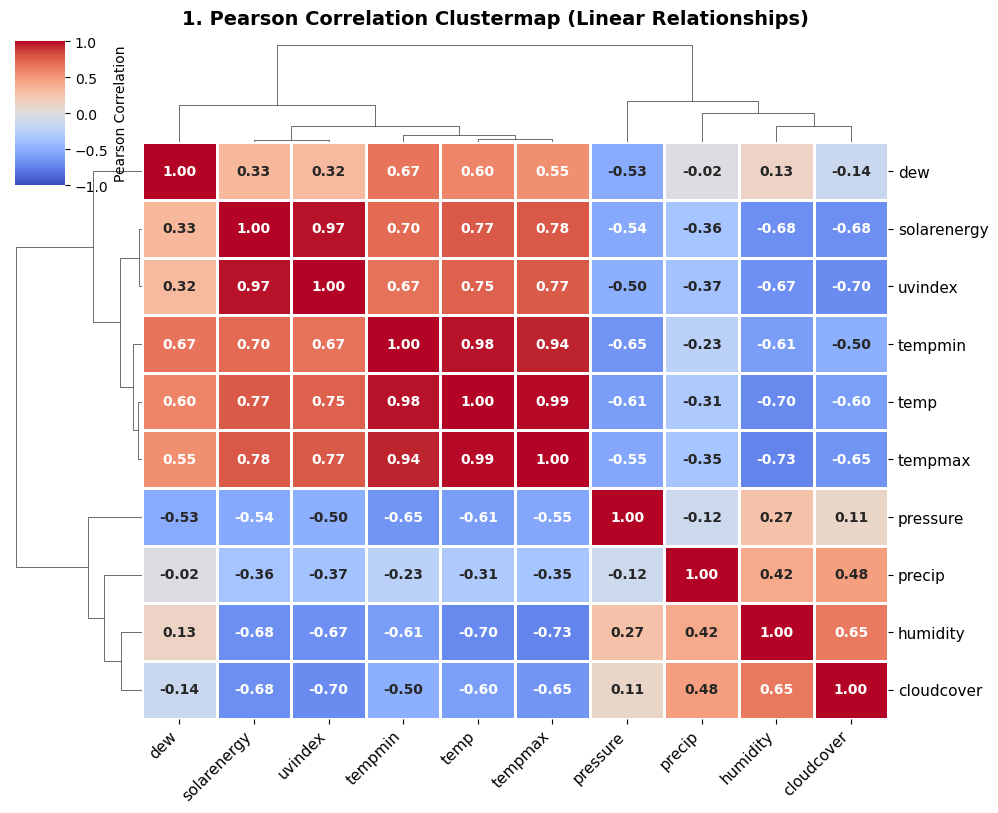

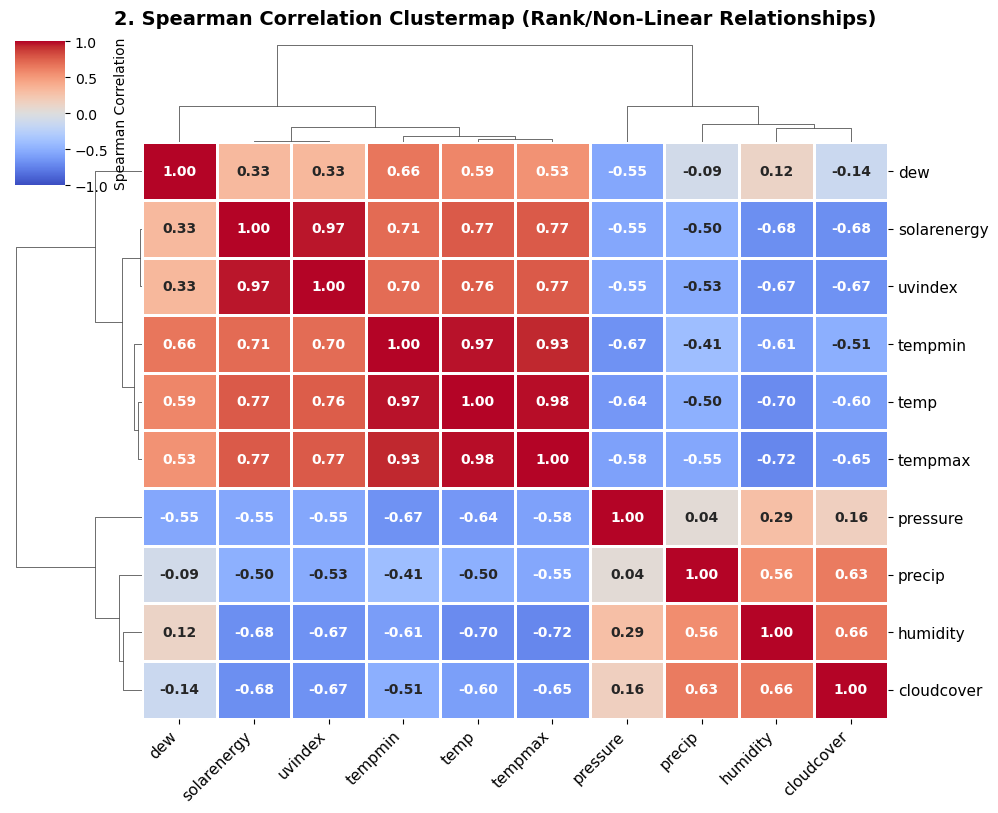

In [95]:
important_columns = [
    'temp',
    'tempmax',
    'tempmin',
    'humidity',
    'dew',
    'precip',
    'pressure',
    'cloudcover',
    'solarenergy',
    'uvindex',
]

existing_cols = [col for col in important_columns if col in weather_df.columns]
corr_data = weather_df[existing_cols]

# =================================================================
# 1. Pearson Clustermap
# =================================================================
corr_matrix_pearson = corr_data.corr(method='pearson')

g1 = sns.clustermap(
    corr_matrix_pearson,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.8,
    vmin=-1,
    vmax=1,
    figsize=(10, 8),
    annot_kws={'size': 10, 'weight': 'bold'}, 
    dendrogram_ratio=(
        0.15,
        0.15,
    ),  
    cbar_kws={'label': 'Pearson Correlation'},
)

# ضبط دوران العناوين وضبط العنوان الرئيسي
plt.setp(g1.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=11)
plt.setp(g1.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)
g1.fig.suptitle(
    '1. Pearson Correlation Clustermap (Linear Relationships)',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)

plt.show()

# =================================================================
# 2. Spearman Clustermap
# =================================================================
corr_matrix_spearman = corr_data.corr(method='spearman')

g2 = sns.clustermap(
    corr_matrix_spearman,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.8,
    vmin=-1,
    vmax=1,
    figsize=(10, 8),
    annot_kws={'size': 10, 'weight': 'bold'},
    dendrogram_ratio=(0.15, 0.15),
    cbar_kws={'label': 'Spearman Correlation'},
)

plt.setp(g2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=11)
plt.setp(g2.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)
g2.fig.suptitle(
    '2. Spearman Correlation Clustermap (Rank/Non-Linear Relationships)',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)

plt.show()

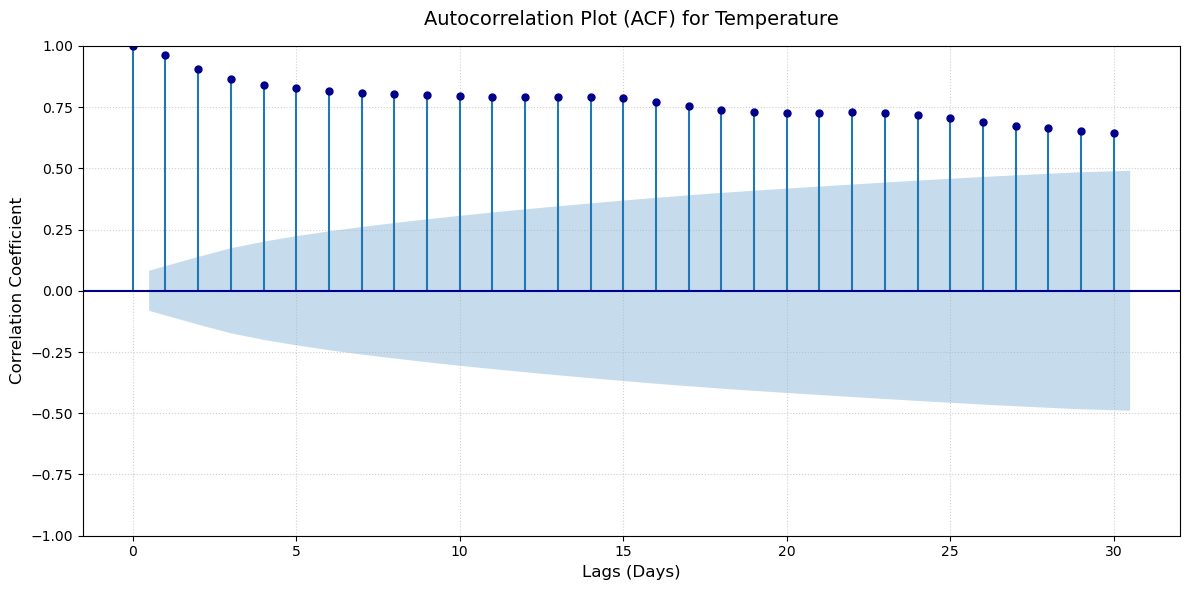

In [96]:
# 1. Create the drawing area
plt.figure(figsize=(12, 6))

# 2. Corrected ACF plot (Removed the problematic vlines_kw argument)
plot_acf(weather_df['temp'].dropna(), lags=30, ax=plt.gca(), color='darkblue')

# 3. Add labels and styling
plt.title("Autocorrelation Plot (ACF) for Temperature", fontsize=14, pad=15)
plt.xlabel("Lags (Days)", fontsize=12)
plt.ylabel("Correlation Coefficient", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Show the clean plot
plt.tight_layout()
plt.show()


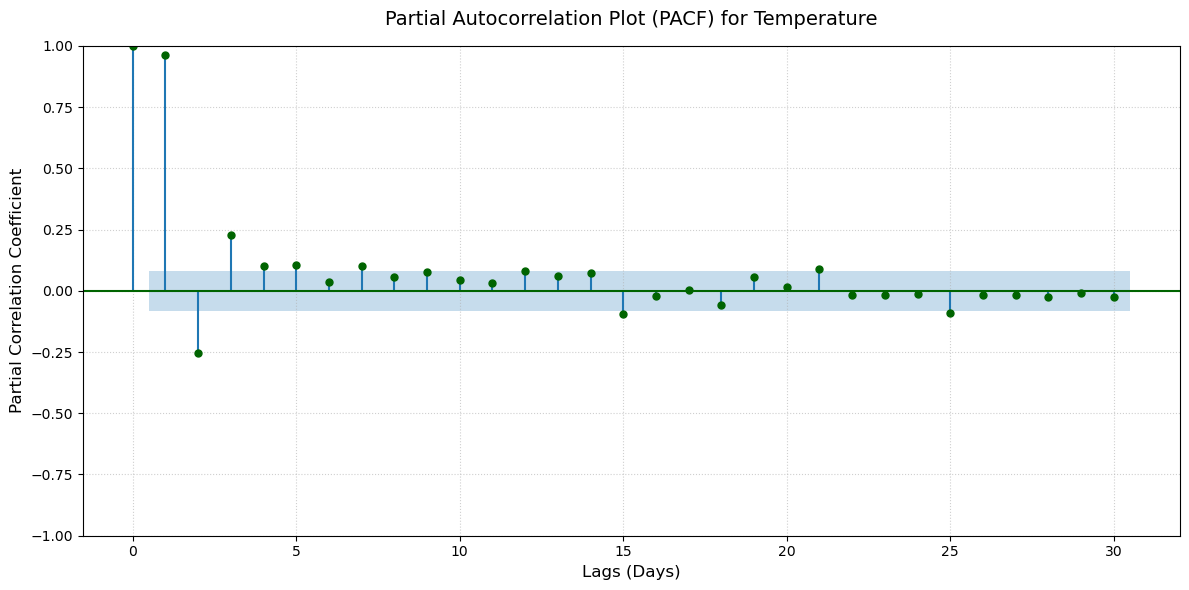

In [97]:
plt.figure(figsize=(12, 6))

plot_pacf(weather_df['temp'].dropna(), lags=30, ax=plt.gca(), color='darkgreen')

plt.title("Partial Autocorrelation Plot (PACF) for Temperature", fontsize=14, pad=15)
plt.xlabel("Lags (Days)", fontsize=12)
plt.ylabel("Partial Correlation Coefficient", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


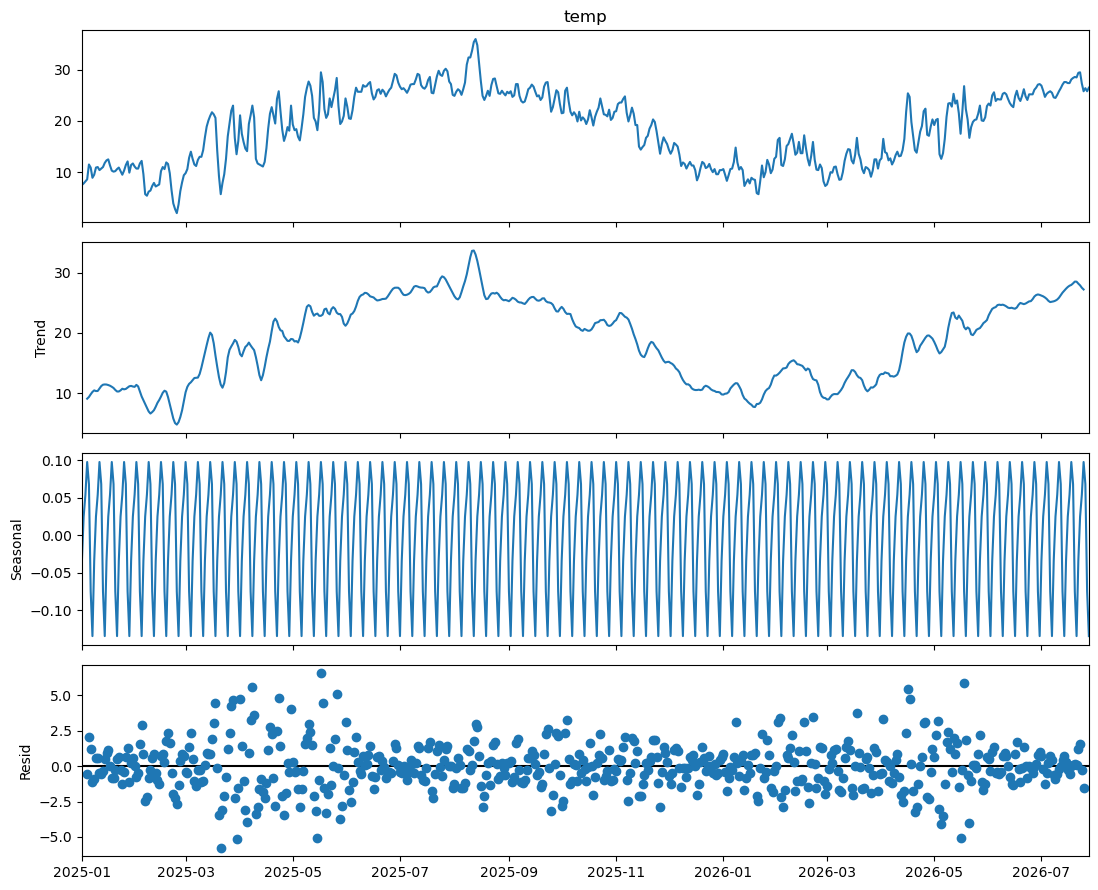

In [98]:
rcParams["figure.figsize"] = 11, 9
decomposition = sm.tsa.seasonal_decompose(
    weather_df["temp"]
)

fig = decomposition.plot()

# 4. عرض اللوحة الشاملة
plt.show()


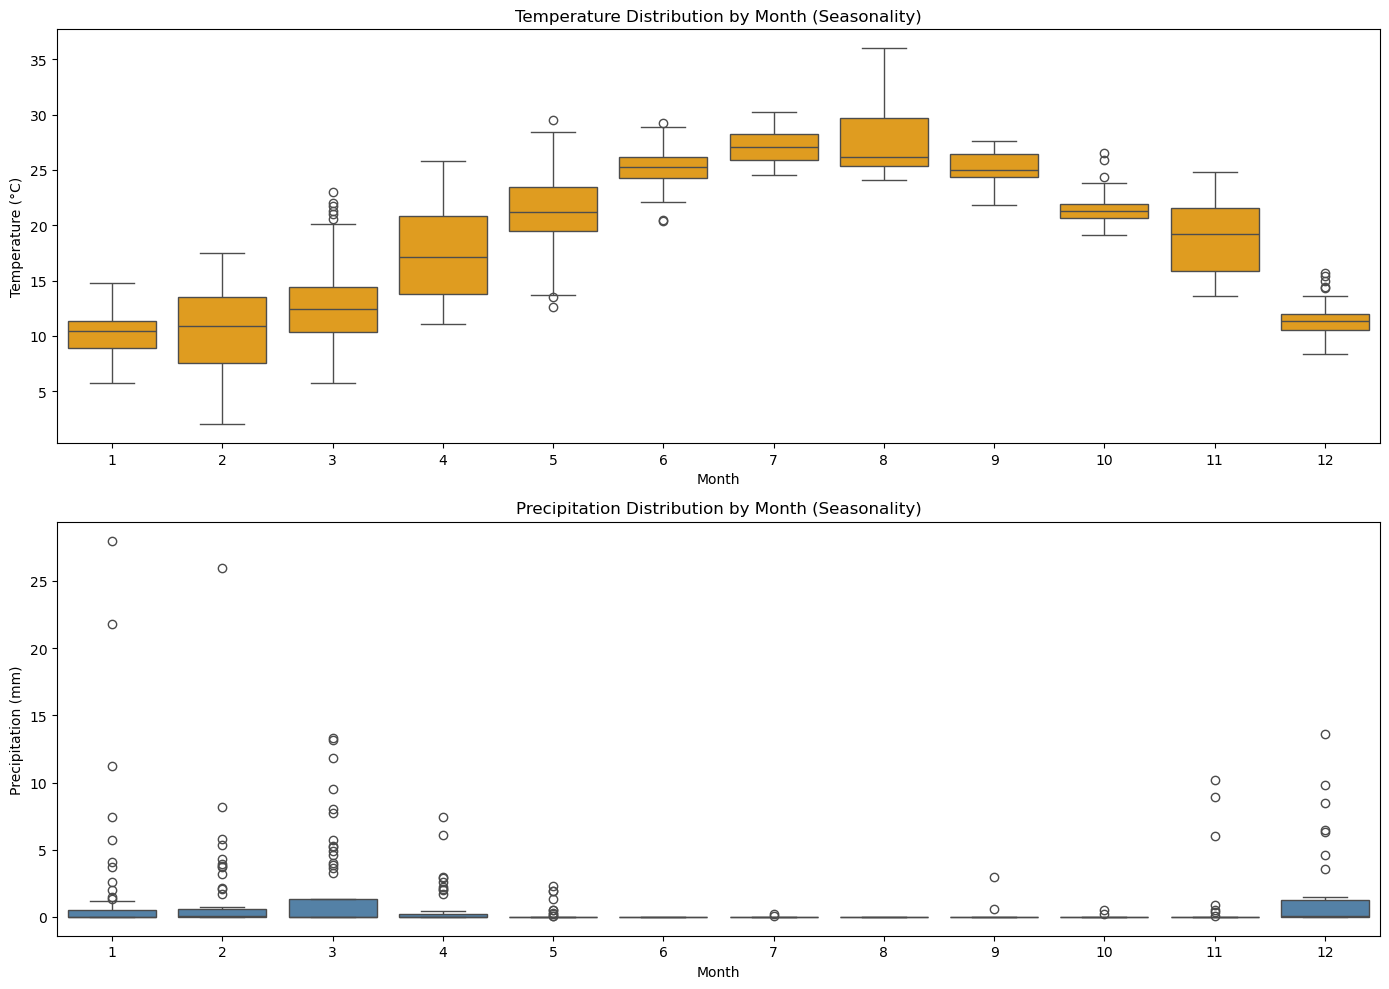

In [99]:
# Seasonality: distribution of temperature and precipitation by calendar month
monthly_view = weather_df.copy()
monthly_view["month"] = monthly_view.index.month

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sns.boxplot(x="month", y="temp", data=monthly_view, ax=axes[0], color="orange")
axes[0].set_title("Temperature Distribution by Month (Seasonality)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Temperature (°C)")

sns.boxplot(x="month", y="precip", data=monthly_view, ax=axes[1], color="steelblue")
axes[1].set_title("Precipitation Distribution by Month (Seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Precipitation (mm)")

plt.tight_layout()
plt.show()


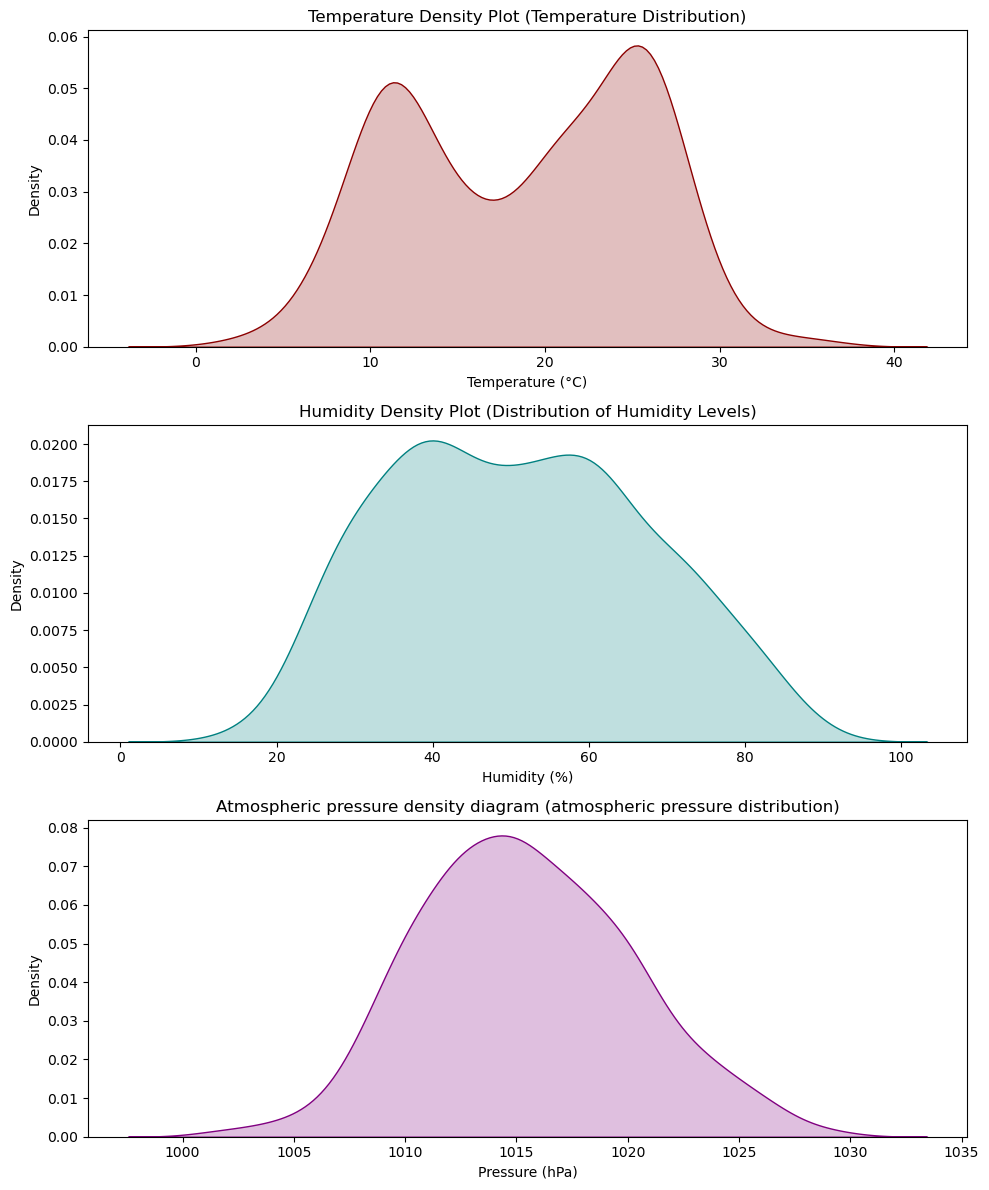

In [100]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

sns.kdeplot(weather_df['temp'].dropna(), fill=True, color='darkred', ax=ax1)
ax1.set_title('Temperature Density Plot (Temperature Distribution)')
ax1.set_xlabel('Temperature (°C)')

sns.kdeplot(weather_df['humidity'].dropna(), fill=True, color='teal', ax=ax2)
ax2.set_title('Humidity Density Plot (Distribution of Humidity Levels)')
ax2.set_xlabel('Humidity (%)')

sns.kdeplot(weather_df['pressure'].dropna(), fill=True, color='purple', ax=ax3)
ax3.set_title('Atmospheric pressure density diagram (atmospheric pressure distribution)')
ax3.set_xlabel('Pressure (hPa)')

plt.tight_layout()
plt.show()


In [101]:
corr_pearson = weather_df[['temp', 'tempmax', 'tempmin', 'humidity']].corr(method='pearson')
print("--- مصفوفة ارتباط بيرسون ---")
print(corr_pearson.round(2))


corr_spearman = weather_df[['temp', 'humidity', 'precip', 'windspeed']].corr(method='spearman')
print("\n--- مصفوفة ارتباط سبيرمان (المقاومة للطفرات) ---")
print(corr_spearman.round(2))


--- مصفوفة ارتباط بيرسون ---
          temp  tempmax  tempmin  humidity
temp      1.00     0.99     0.98     -0.70
tempmax   0.99     1.00     0.94     -0.73
tempmin   0.98     0.94     1.00     -0.61
humidity -0.70    -0.73    -0.61      1.00

--- مصفوفة ارتباط سبيرمان (المقاومة للطفرات) ---
           temp  humidity  precip  windspeed
temp       1.00     -0.70   -0.50       0.23
humidity  -0.70      1.00    0.56      -0.02
precip    -0.50      0.56    1.00       0.20
windspeed  0.23     -0.02    0.20       1.00


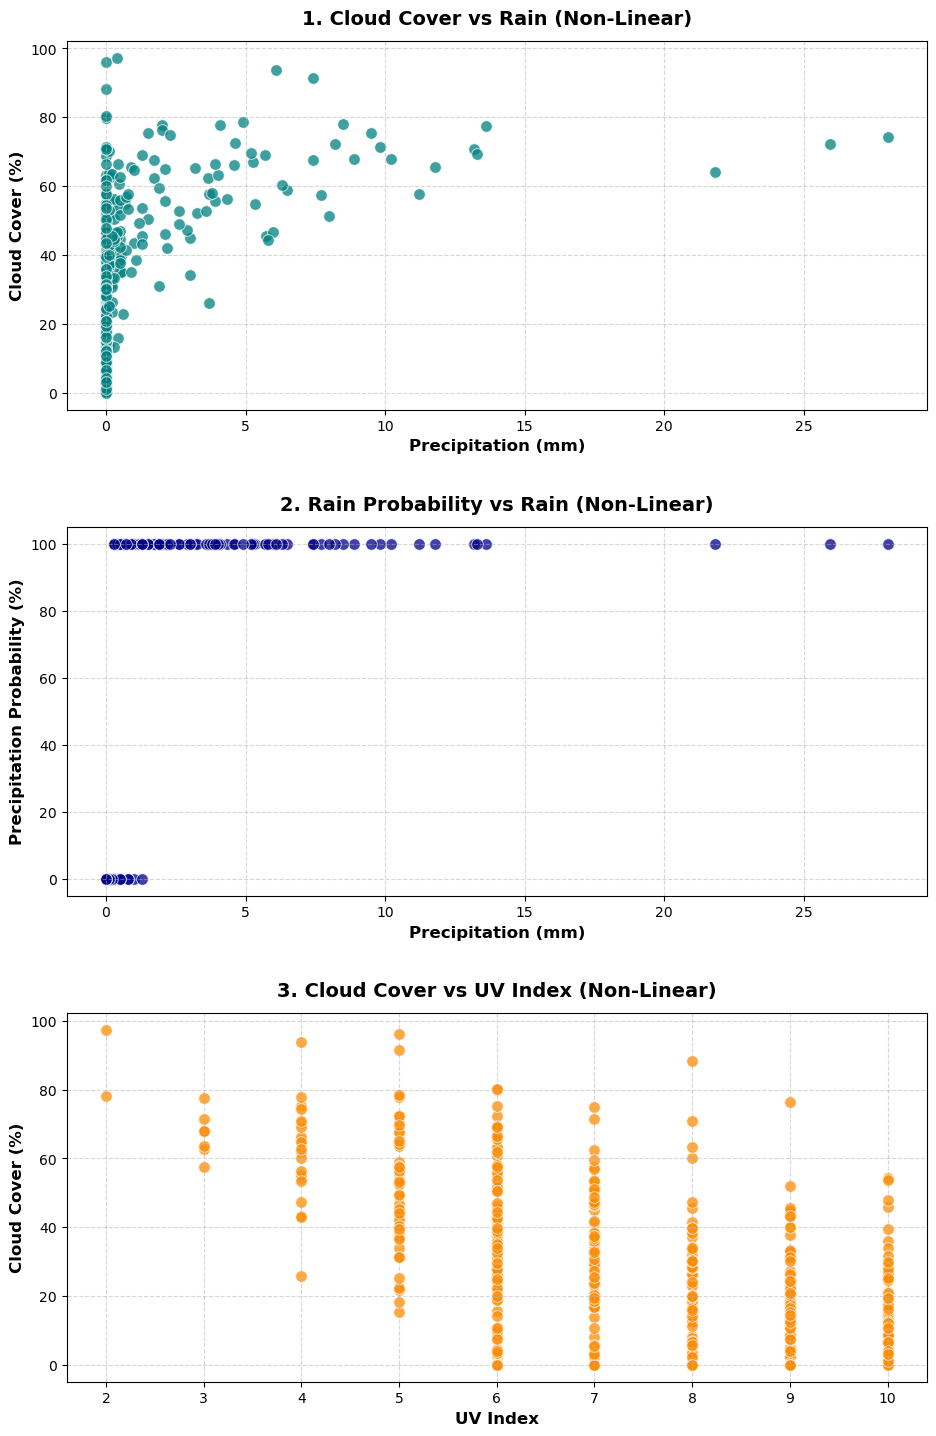

In [102]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

sns.scatterplot(
    x='precip',
    y='cloudcover',
    data=weather_df,
    ax=ax1,
    color='teal',
    alpha=0.75,
    s=70,
)
ax1.set_title(
    '1. Cloud Cover vs Rain (Non-Linear)', fontsize=14, fontweight='bold', pad=12
)
ax1.set_ylabel('Cloud Cover (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Precipitation (mm)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x='precip',
    y='precipprob',
    data=weather_df,
    ax=ax2,
    color='darkblue',
    alpha=0.75,
    s=70,
)
ax2.set_title(
    '2. Rain Probability vs Rain (Non-Linear)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax2.set_ylabel('Precipitation Probability (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Precipitation (mm)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x='uvindex',
    y='cloudcover',
    data=weather_df,
    ax=ax3,
    color='darkorange',
    alpha=0.75,
    s=70,
)
ax3.set_title(
    '3. Cloud Cover vs UV Index (Non-Linear)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax3.set_ylabel('Cloud Cover (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('UV Index', fontsize=12, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()

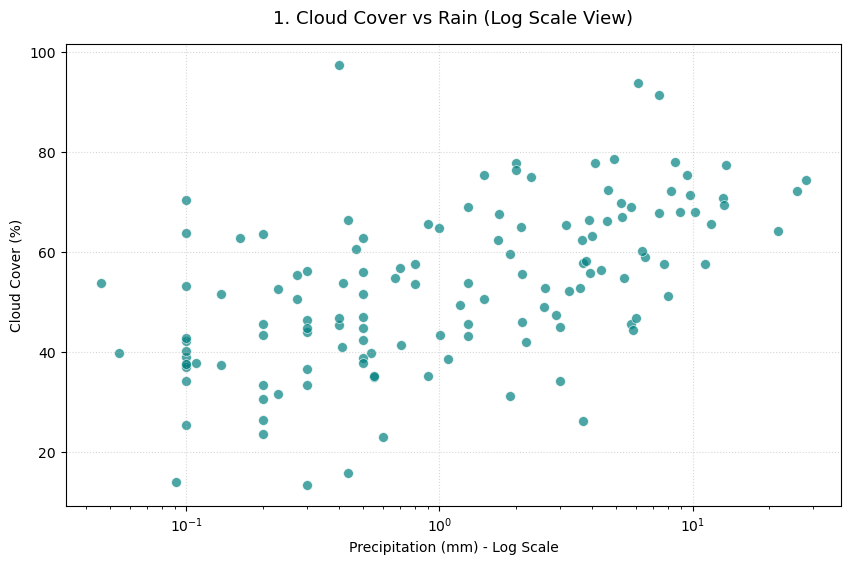

In [103]:
rainy_days = weather_df[weather_df["precip"] > 0]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="precip", y="cloudcover", data=rainy_days, color="teal", alpha=0.7, s=50
)

plt.xscale("log")

plt.title("1. Cloud Cover vs Rain (Log Scale View)", fontsize=13, pad=15)
plt.xlabel("Precipitation (mm) - Log Scale")
plt.ylabel("Cloud Cover (%)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()


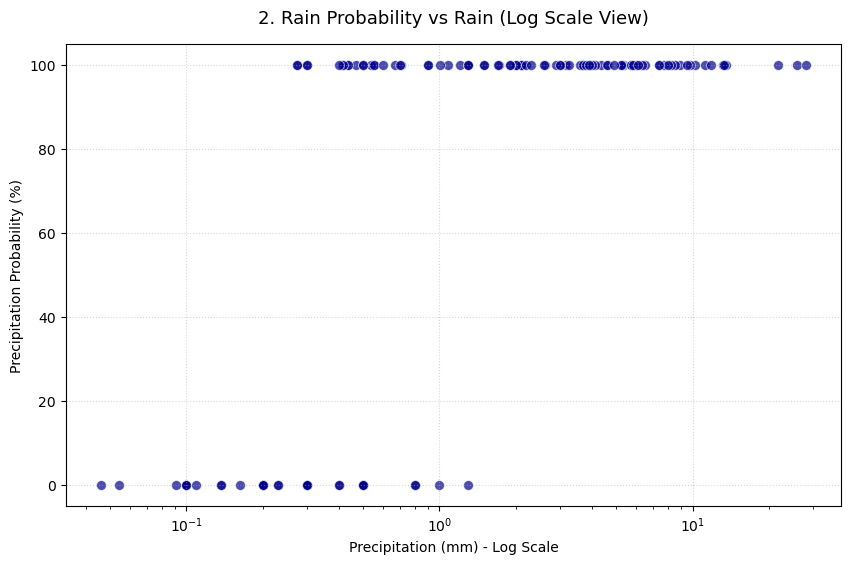

In [104]:
rainy_days = weather_df[weather_df["precip"] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="precip", y="precipprob", data=rainy_days, color="darkblue", alpha=0.7, s=50
)

plt.xscale("log")
plt.ylim(-5, 105)  

plt.title("2. Rain Probability vs Rain (Log Scale View)", fontsize=13, pad=15)
plt.xlabel("Precipitation (mm) - Log Scale")
plt.ylabel("Precipitation Probability (%)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()


In [105]:
# Save the final cleaned dataset (after gap-filling and feature columns) used for the analysis above
weather_df.to_csv("weather_data_final_clean.csv")
print("Final cleaned dataset saved to weather_data_final_clean.csv")

Final cleaned dataset saved to weather_data_final_clean.csv
